<a href="https://colab.research.google.com/github/ARCILAEDNA/Sprint8-Final-Project/blob/main/S8_Student_Version_Project_NovaRetail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sprint 8 Proyecto - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv('novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- 'nivel_ingreso'
- 'visitas_mes'
- 'compras_mes'
- 'gasto_publicidad_dirigida'
- 'satisfaccion'
- 'ingreso_anual'

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna edad está como float64, debe ser transformada a int64.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de dato
df['edad']=df['edad'].astype(int)

In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
variables_numericas= ["edad",
                      "nivel_ingreso",
                      "visitas_mes",
                      "compras_mes",
                      "gasto_publicidad_dirigida",
                      "satisfaccion",
                      "ingreso_anual"]
df[variables_numericas].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


✍️ **Comentario**

Diagnóstico inicial de variables numéricas

- "edad" — La edad promedio es de 38,26 años, con mediana de 38 y un rango de 18 a 75, lo que describe una base de clientes adulta y concentrada entre los 30 y 46 años (percentiles 25 y 75). Distribución bastante simétrica.
  
- "nivel_ingreso"- tiene media de 30.019,70 y mediana de 30.023,75, con un máximo de 74.790,84 que queda a 4,55 desviaciones estándar de la media. Distribución asimétrica.

- "visitas_mes"- rondan las 10 (mediana de 10, desviación de 3,16), con un máximo de 25 que también parece un valor alto frente al resto.

- "compras_mes"- Las compras tienen media de 1,21 y mediana de 1, con un percentil 25 igual a 0, así que al menos una cuarta parte de los registros no compró en el mes, y el máximo llega a 8. Distribución más asimétrica.

- "gasto_publicidad_dirigida"- tiene media de 20,15 y mediana de 19,73, con un mínimo de 0 (hay registros sin inversión publicitaria) y un máximo de 75,51, muy por encima del percentil 75 (27,29). Distribución más asimétrica.

- "satisfaccion"- promedia 3,60 en una escala que parece ir de 1 a 5, con la mitad central entre 3,1 y 4,1. Que haya decimales sugiere que es un promedio de calificaciones.

- "ingreso_anual"- Su media es de 36.594,18, pero la mediana es de 30.705 y la desviación estándar (34.484,89) es casi igual a la media, lo que indica una distribución fuertemente sesgada a la derecha. Además, el percentil 25 es 0, es decir, al menos una cuarta parte de los registros tiene ingreso anual igual a cero, mientras el máximo llega a 244.690.

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles

print(df['miembro_premium'].unique())
print(df['miembro_premium'].value_counts())
print()
print(df['abandono'].unique())
print(df['abandono'].value_counts())

[0 1]
miembro_premium
0    12911
1     2089
Name: count, dtype: int64

[0 1]
abandono
0    12739
1     2261
Name: count, dtype: int64



✍️ **Comentario**:

Diagnóstico inicial de variables binarias

- `miembro_premium` — tiene dos valores: 0 y 1. No  hay valores nulos o sentinelas. Hay 2089 miembros Premium (13.93%).
- `abandono` — tiene dos valores: 0 y 1. No  hay valores nulos o sentinelas. Hay 2261 abandonos(15.07%).


#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
print(df['id_cliente'].unique())
print(df['tipo_dispositivo'].unique())
print(df['region'].unique())

['CL-100000' 'CL-100001' 'CL-100002' ... 'CL-114997' 'CL-114998'
 'CL-114999']
['móvil' 'tablet' 'escritorio']
['norte' 'sur' 'este' 'oeste']


In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print(df['tipo_dispositivo'].value_counts())
print()
print(df['region'].value_counts())

tipo_dispositivo
móvil         9818
escritorio    3720
tablet        1462
Name: count, dtype: int64

region
norte    4395
oeste    3810
sur      3726
este     3069
Name: count, dtype: int64


✍️ **Comentario**:

Diagnóstico inicial de variables categóricas
En tipo_dispositivo: móvil domina claramente (9818), seguido de escritorio (3720) y tablet (1462).
En region: las cuatro regiones están bastante parejas, con norte ligeramente arriba (4395) y este un poco más baja (3069).

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.



## Sección 3 - Visualizaciones

### Heatmap

Text(0.5, 1.0, 'Heatmap de correlaciones-Novaretail')

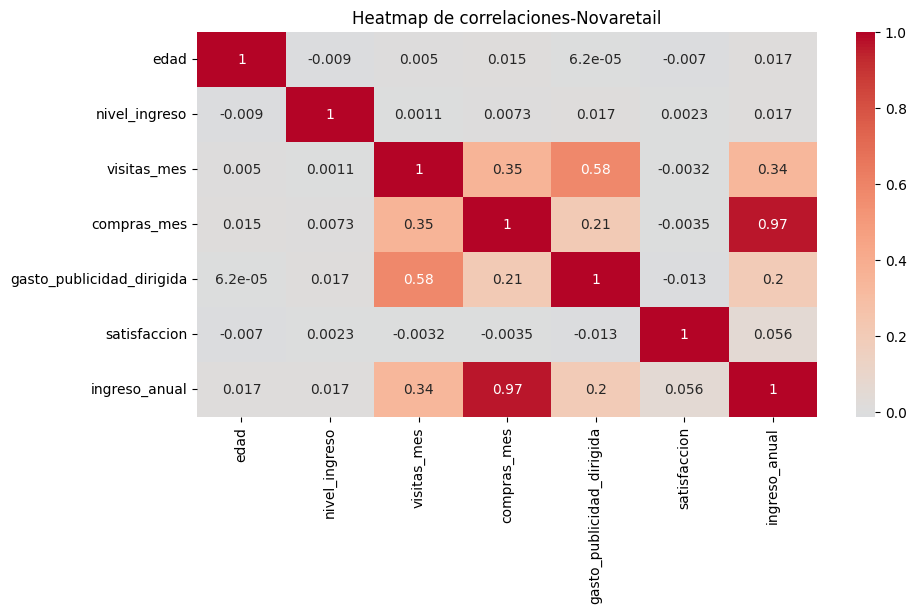

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
corr= df[variables_numericas].corr()
plt.figure(figsize=(10,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Heatmap de correlaciones-Novaretail")


✍️ **Comentario**:

Observaciones generales (Heatmap)  
- Se observan correlaciones fuertes positivas, y no aparece ninguna correlación negativa relevante. La primera correlación en intensidad (0,97) es ingreso_anual y compras_mes. La segunda asociación en intensidad es la de visitas_mes con gasto_publicidad_dirigida (0,58), de magnitud moderada a alta. Esta relación puede deberse a que la publicidad dirigida atrae visitas, a que se invierte más en los clientes que ya visitan mucho, o a un tercer factor, y los datos por sí solos no permiten distinguirlo. Después vienen asociaciones moderadas o bajas: visitas_mes con compras_mes (0,35) y con ingreso_anual (0,34), y gasto_publicidad_dirigida con compras_mes (0,21) y con ingreso_anual (0,20). Entre las relaciones débiles o irrelevantes destaca que edad y nivel_ingreso no muestran asociación lineal con prácticamente ninguna otra variable, con valores entre -0,009 y 0,017, es decir, esencialmente cero. Lo mismo ocurre con satisfaccion, cuyas correlaciones con visitas, compras y gasto publicitario son prácticamente nulas (entre -0,013 y -0,0032), con una única excepción muy pequeña frente a ingreso_anual (0,056), que apenas rebasa el ruido.


Observaciones respecto a `ingreso_anual`  
- Presenta una correlación fuerte con compras_mes (0,97), una asociación casi lineal. Se necesita investigar si ingreso_anual es el ingreso generado por el cliente para el negocio, cruzando las variables y revisando el diccionario de datos. Una correlación tan alta también sugiere que ambas variables miden en buena medida lo mismo, lo que habría que tener presente si se van a usar juntas en un modelo o si una de ellas se usara para explicar a la otra.

### Scatterplot general

El heatmap ya mostró que la mayoría de los pares tienen correlaciones lineales esencialmente nulas: edad, nivel_ingreso y satisfaccion casi no se relacionan con nada, así que una matriz completa dedicaría la mayor parte de sus paneles a nubes sin estructura. Además son 15000 datos. Sería muy complicado de leer. Por lo tanto no se genera un scatterplot general.

### Scatterplot para pares clave

Text(0.5, 1.0, 'Visitas vs. gasto en publicidad dirigida')

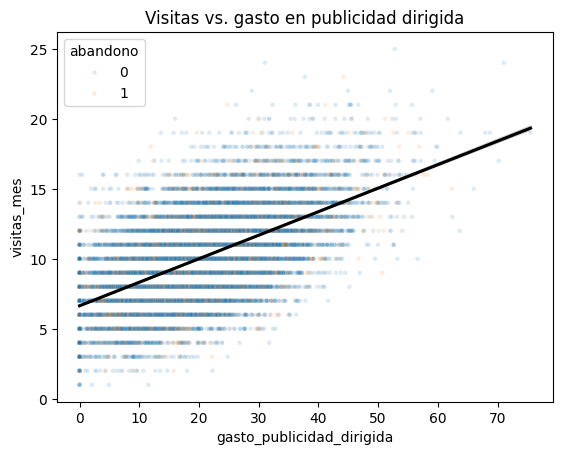

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes
#visitas_mes frente a gasto_publicidad_dirigida

sns.scatterplot(data=df, x="gasto_publicidad_dirigida", y="visitas_mes",
                hue="abandono", alpha=0.15, s=10)
sns.regplot(data=df, x="gasto_publicidad_dirigida", y="visitas_mes",
            scatter=False, color="black")
plt.title("Visitas vs. gasto en publicidad dirigida")

Text(0.5, 1.0, 'Compras mes vs. ingreso anual')

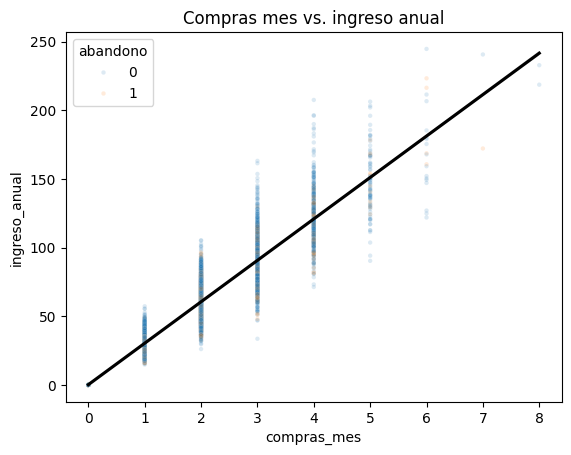

In [ ]:
#compras_mes frente a ingreso_anual

sns.scatterplot(data=df, x="compras_mes", y="ingreso_anual",
                hue="abandono", alpha=0.15, s=10)
sns.regplot(data=df, x="compras_mes", y="ingreso_anual",
            scatter=False, color="black")
plt.title("Compras mes vs. ingreso anual")


✍️ **Comentario**:   

Observaciones iniciales (Scatterplot)

**visitas_mes vs gasto_publicidad_dirigida**
- Dirección positiva, dispersión media, presencia de outliers sin posible colinealidad.

**compras_mes vs ingreso_anual**
- Dirección positiva, dispersión baja, presencia de outliers y posible colinealidad.

## Sección 4 - Coeficientes de correlación y evidencia numérica


### Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes
compras_ingreso_pearson = df['compras_mes'].corr(df['ingreso_anual'],method='pearson')
print('Correlación de Pearson para compras e ingreso anual', compras_ingreso_pearson)

Correlación de Pearson para compras e ingreso anual 0.9671485435708559


In [ ]:
# Calcular correlación entre variables relevantes
visitas_gastos_pearson= df['visitas_mes'].corr(df['gasto_publicidad_dirigida'],method='pearson')
print('Correlación de Pearson para visitas y gasto publicitario', visitas_gastos_pearson)

Correlación de Pearson para visitas y gasto publicitario 0.5789472719412829


In [ ]:
# Calcular correlación entre variables relevantes
visitas_gastos_spearman= df['visitas_mes'].corr(df['gasto_publicidad_dirigida'],method='spearman')
print('Correlación de Spearman para visitas y gasto publicitario', visitas_gastos_spearman)

Correlación de Spearman para visitas y gasto publicitario 0.5592673242622609


In [ ]:
# Calcular correlación entre variables relevantes
visitas_gastos_pearson= df['visitas_mes'].corr(df['ingreso_anual'],method='pearson')
print('Correlación de Pearson para visitas e ingreso anual', visitas_gastos_pearson)

Correlación de Pearson para visitas e ingreso anual 0.3371466432498748


In [ ]:
# Calcular correlación entre variables relevantes
visitas_gastos_spearman= df['visitas_mes'].corr(df['ingreso_anual'],method='spearman')
print('Correlación de Spearman para visitas e ingreso anual', visitas_gastos_spearman)

Correlación de Spearman para visitas e ingreso anual 0.32095369737696483


In [ ]:
# Calcular correlación entre variables relevantes
visitas_gastos_pearson= df['gasto_publicidad_dirigida'].corr(df['ingreso_anual'],method='pearson')
print('Correlación de Pearson para gasto publicitario e ingreso anual', visitas_gastos_pearson)

Correlación de Pearson para gasto publicitario e ingreso anual 0.19748270182341018


In [ ]:
# Calcular correlación entre variables relevantes
visitas_gastos_spearman= df['gasto_publicidad_dirigida'].corr(df['ingreso_anual'],method='spearman')
print('Correlación de Spearman para gasto publicitario e ingreso anual', visitas_gastos_spearman)

Correlación de Spearman para gasto publicitario e ingreso anual 0.18499874477115502


✍️ **Comentario**:

Observaciones de correlación
**compras_mes vs ingreso_anual**
- Dirección positiva, magnitud alta: 0.967, posible colinealidad.
  
**visitas_mes vs gasto_publicidad_dirigida**
- Dirección positiva, magnitud Pearson media:0.579, magnitud Spearman media: 0.578, sin posible colinealidad.

**visitas_mes vs ingreso_anual**
- Dirección positiva, magnitud Pearson baja: 0.337, magnitud Spearman baja: 0.320 sin posible colinealidad.

**gasto_publicidad_dirigida vs ingreso_anual**
- Dirección positiva, magnitud baja: 0.197, magnitud Spearman baja: 0.185 sin posible colinealidad.

### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes

from scipy.stats import pointbiserialr

pointbiserialr(df['miembro_premium'],df['ingreso_anual'])

SignificanceResult(statistic=np.float64(0.0930994396198017), pvalue=np.float64(3.0943076155263697e-30))

In [ ]:
# Calcular correlación entre variables relevantes

pointbiserialr(df['abandono'],df['ingreso_anual'])

SignificanceResult(statistic=np.float64(-0.0028239340216172073), pvalue=np.float64(0.7294691719078419))

✍️ **Comentario**:

Observaciones Punto-biserial

**miembro_premium vs ingreso_anual**
- Relación lineal dêbil: 0.093 pero estadísticamente significativo:3.09e-30. El efecto de ser miembro premium sobre el ingreso anual existe, pero es pequeño en magnitud.

**abandono vs ingreso_anual**
- Relación lineal prácticamente nula: 0.003, sin significancia estadística: 0.729. No se observa asociación lineal.


### V de Cramér

In [ ]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency

col1='region'
col2='tipo_dispositivo'

def cramer_v (df, col1, col2):
    tabla = pd.crosstab(df[col1],df[col2])
    chi2, p_value, dof, expected= chi2_contingency(tabla)
    n= tabla.values.sum()
    v= np.sqrt(chi2/(n*(min(tabla.shape)-1)))
    print (f"V de Cramer({col1} vs {col2}):", v)

In [ ]:
# Aplicar V de Cramér en variables relevantes
cramer_v (df, col1, col2)

V de Cramer(region vs tipo_dispositivo): 0.012378338407739397


✍️ **Comentario**:

V de Cramér:
La relación entre región y tipo de dispositivo es casi nula (v= 0.0124)


## Sección 5 - Interpretación de resultados para el negocio


---

### Hallazgo 1 — Las compras mensuales presentan la asociación más fuerte con el ingreso anual

**Evidencia visual:** En el scatterplot de compras_mes frente a ingreso_anual se observa una dirección positiva, con dispersión baja y presencia de outliers. Los puntos siguen de cerca la línea de tendencia, y el heatmap muestra esta relación como la más intensa de toda la matriz.

**Evidencia numérica:** La correlación de Pearson entre compras_mes e ingreso_anual es de 0,967 (0,97 en el heatmap), la más alta del análisis y de magnitud alta. Como referencia, ambas variables tienen un percentil 25 igual a 0: al menos una cuarta parte de los registros no registró compras en el mes ni ingreso anual.

**Interpretación**  Los clientes con más compras mensuales tienden a registrar un ingreso anual mayor, y los que no compran tienden a ubicarse en los valores más bajos de ingreso. La asociación es casi lineal, de modo que compras_mes es el indicador de comportamiento que más se mueve junto con ingreso_anual en este conjunto de datos.

**No podemos afirmar** No podemos afirmar que aumentar las compras mensuales produzca un mayor ingreso anual, ni lo contrario. Tampoco podemos afirmar que se trate de dos fenómenos independientes: una correlación tan alta sugiere que ambas variables miden en buena medida lo mismo, por lo que su relación podría ser en parte de naturaleza definicional. Está pendiente verificar en el diccionario de datos cómo se calcula ingreso_anual, y no es recomendable usar una variable para explicar a la otra en un modelo sin esa validación.

**Implicación de negocio** compras_mes puede utilizarse como indicador de seguimiento junto al ingreso anual, y la segmentación de clientes por frecuencia de compra es un punto de partida razonable para el equipo de Crecimiento y retención. Antes de basar decisiones en esta relación, conviene confirmar la definición de ambas métricas.


### Hallazgo 2 — Visitas y gasto en publicidad dirigida muestran asociaciones positivas con el ingreso anual, pero de menor magnitud

**Evidencia visual:** El heatmap muestra ambas variables con asociaciones moderadas a bajas respecto de ingreso_anual. El scatterplot de visitas_mes frente a gasto_publicidad_dirigida presenta dirección positiva y dispersión media, con presencia de outliers.

**Evidencia numérica:** visitas_mes e ingreso_anual tienen una correlación de Pearson de 0,337 y de Spearman de 0,320 (magnitud baja). gasto_publicidad_dirigida e ingreso_anual tienen una correlación de Pearson de 0,197 y de Spearman de 0,185 (magnitud baja). Entre las propias variables de comportamiento, visitas_mes y gasto_publicidad_dirigida registran una correlación de Pearson de 0,579 y de Spearman de 0,578 (magnitud media). Las correlaciones con compras_mes son de 0,35 para visitas y de 0,21 para gasto publicitario.

**Interpretación**  Los clientes con más visitas mensuales tienden a presentar un ingreso anual algo mayor, y lo mismo ocurre, de forma más débil, con el gasto publicitario asignado. La coincidencia entre Pearson y Spearman indica que el patrón es consistente y no depende de unos pocos valores extremos. El gasto publicitario se asocia más fuertemente con las visitas que con el ingreso anual, de modo que su relación con este último podría pasar parcialmente por la actividad en la plataforma.

**No podemos afirmar**  No podemos afirmar que la publicidad dirigida atraiga visitas ni que las visitas generen ingreso. La asociación entre visitas y gasto publicitario puede deberse a que la publicidad atrae tráfico, a que se invierte más en clientes que ya visitan con frecuencia, o a un tercer factor no medido; los datos no permiten distinguir entre estas explicaciones. Tampoco podemos afirmar que el gasto publicitario sea rentable, pues la asociación con el ingreso anual es baja.

**Implicación de negocio**  Las visitas pueden considerarse una señal de actividad complementaria a las compras, pero no un sustituto. En cuanto a la publicidad dirigida, la evidencia actual no justifica por sí sola aumentar o reducir la inversión; se requiere un diseño que permita evaluar su efecto de forma controlada.

### Hallazgo 3 — Ser miembro premium presenta una asociación débil, aunque estadísticamente significativa, con el ingreso anual

**Evidencia visual:**  No se generó un gráfico específico para esta relación en el notebook. Se recomienda incorporar una comparación de la distribución de ingreso_anual entre miembros premium y no premium para respaldar visualmente este hallazgo.

**Evidencia numérica:** La correlación punto-biserial entre miembro_premium e ingreso_anual es de 0,093, con un valor p de 3,09e-30. Hay 2089 miembros premium (13,93 % del total de 15000 registros).

**Interpretación**  Existe una relación positiva entre pertenecer al grupo premium y tener un ingreso anual más alto, pero su magnitud es pequeña. El valor p tan bajo refleja en buena medida el tamaño de la muestra, por lo que la significancia estadística no debe confundirse con relevancia práctica.

**No podemos afirmar**  No podemos afirmar que la suscripción premium incremente el ingreso anual de los clientes. Es posible que los clientes de mayor actividad sean quienes optan por la suscripción, o que ambos rasgos respondan a otros factores no observados.

**Implicación de negocio**  El estatus premium, por sí solo, es un segmento poco informativo para anticipar el ingreso anual. Resulta más útil cruzarlo con la frecuencia de compra antes de tomar decisiones sobre la estrategia de suscripción.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**

- Correlación ≠ causalidad: los resultados describen asociaciones, no efectos.
La correlación de 0,967 entre compras_mes e ingreso_anual sugiere que ambas variables podrían medir en buena medida lo mismo; falta validar su definición en el diccionario de datos.
Los coeficientes de Pearson, Spearman y punto-biserial solo capturan relaciones lineales o monótonas; no detectan patrones no lineales ni interacciones.
ingreso_anual tiene una distribución fuertemente sesgada a la derecha, con al menos 25 % de registros en cero, lo que puede influir en los coeficientes.
Los datos son una fotografía del cierre de 2024: no hay dimensión temporal ni orden de ocurrencia entre las variables.
No se evaluó directamente la relación de region y tipo_dispositivo con ingreso_anual.
El análisis no incluyó el tratamiento de outliers ni el control simultáneo de varias variables.
Posibles variables no medidas: categoría y precio de los productos comprados, antigüedad del cliente, canal de adquisición, descuentos y promociones recibidos, devoluciones, frecuencia y recencia de compra, y tamaño del pedido o ticket promedio.

### **Próximos pasos**

- Segmentación
Comparar ingreso_anual por region y tipo_dispositivo (medias, medianas y distribución).
Segmentar por frecuencia de compra (sin compras, 1, 2 o más) y por estatus premium.
Separar a los clientes con ingreso anual igual a cero del resto y analizarlos por aparte.
Cruzar premium con frecuencia de compra y con visitas.

- Análisis futuros
Validar con el equipo de datos la definición de ingreso_anual y su relación con compras_mes.
Ajustar un modelo multivariable que evalúe el aporte de cada variable de forma conjunta, cuidando la colinealidad.
Explorar relaciones no lineales con correlaciones por rangos, categorización o modelos basados en árboles.
Incorporar la dimensión temporal si se dispone de datos mensuales.

- Experimentos
Prueba A/B sobre el gasto en publicidad dirigida, con grupo de control y asignación aleatoria.
Prueba A/B de una oferta de suscripción premium a clientes comparables.
Piloto de campañas de retención dirigidas a segmentos de baja frecuencia de compra, medido con un grupo de control.
